# F1 — EDA Titanic: Exploración Inicial Reproducible
## MCDI503 Exploración Inteligente para la Ciencia de Datos | Grupo 4

---

### § I — Identificación del proyecto

| Campo | Detalle |
|---|---|
| **Curso** | MCDI503 — Exploración Inteligente para la Ciencia de Datos |
| **Fase** | Fase 1 — Avance sumativo |
| **Dataset** | Titanic (seaborn built-in) |
| **Propósito** | Implementar el primer ciclo de EDA reproducible: carga, revisión, exploración preliminar, decisiones iniciales y hallazgos exploratorios del dataset Titanic. |
| **Integrantes** | Marcelo Corro · Carolina Cortés · Pedro Espinoza · Juan Pablo Valdebenito |
| **Fecha** | Septiembre 2026 |

> **Nota de reproducibilidad:** este notebook se ejecuta completamente desde cero con *Kernel → Restart & Run All*. El dataset se carga directamente desde la librería `seaborn`, sin dependencias de archivos externos.

---
## § II — Contexto y objetivo exploratorio

### § II.1 — Contexto del problema

El hundimiento del RMS Titanic en abril de 1912 es uno de los desastres marítimos más documentados
de la historia. De los 2.224 pasajeros y tripulantes a bordo, sobrevivieron aproximadamente 710
personas (≈32%). El acceso a los botes salvavidas estuvo fuertemente condicionado por factores
socioeconómicos, demográficos y operativos, lo que convierte a este dataset en un caso de estudio
canónico para el análisis exploratorio de datos: presenta una variable objetivo binaria clara
(`survived`), variables de tipo mixto (numéricas y categóricas), valores faltantes estructurales
y patrones de relación entre variables de distinta naturaleza.

El dataset **Titanic** disponible en `seaborn` contiene 891 observaciones y 15 variables que
describen a cada pasajero: clase de viaje, sexo, edad, número de familiares a bordo, tarifa
pagada, puerto de embarque y si sobrevivió o no. Su riqueza analítica lo hace ideal para cubrir
la totalidad del recorrido técnico de las fases del proyecto.

### § II.2 — Objetivo exploratorio

> Comprender la estructura general del dataset Titanic, identificar sus características técnicas
> (tipos de datos, valores faltantes, distribuciones), y detectar patrones iniciales de
> asociación entre las variables y la supervivencia, como base reproducible para las fases
> posteriores del proyecto.

### § II.3 — Preguntas exploratorias iniciales

1. ¿Cuál es la distribución de supervivientes y no supervivientes en el dataset?
2. ¿Qué variables presentan valores faltantes y en qué magnitud?
3. ¿Existen diferencias en la tasa de supervivencia según sexo, clase de viaje y edad?
4. ¿Cómo se distribuye la variable `age` y qué implicaciones tiene para el análisis?
5. ¿Hay variables redundantes o derivadas que puedan simplificarse para el análisis?


---
## § III — Carga y revisión inicial de datos


In [ ]:
# § III.1 — Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Librerías cargadas correctamente.")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")
print(f"  seaborn {sns.__version__}")


Librerías cargadas correctamente.
  pandas  2.2.3
  numpy   2.1.3
  seaborn 0.13.2


In [ ]:
# § III.2 — Carga del dataset desde seaborn
df = sns.load_dataset('titanic')

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(5)


Dataset cargado: 891 filas × 15 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# § III.3 — Tipos de datos y estructura general
print("=== TIPOS DE DATOS ===")
print(df.dtypes)
print(f"\nVariables numéricas : {df.select_dtypes(include='number').columns.tolist()}")
print(f"Variables categóricas: {df.select_dtypes(include='object').columns.tolist()}")
print(f"Variables booleanas  : {df.select_dtypes(include='bool').columns.tolist()}")


=== TIPOS DE DATOS ===
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Variables numéricas : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Variables categóricas: ['sex', 'embarked', 'who', 'embark_town', 'alive']
Variables booleanas  : ['adult_male', 'alone']


=== VALORES FALTANTES ===
             Faltantes  Porcentaje
deck               688     77.2200
age                177     19.8700
embarked             2      0.2200
embark_town          2      0.2200


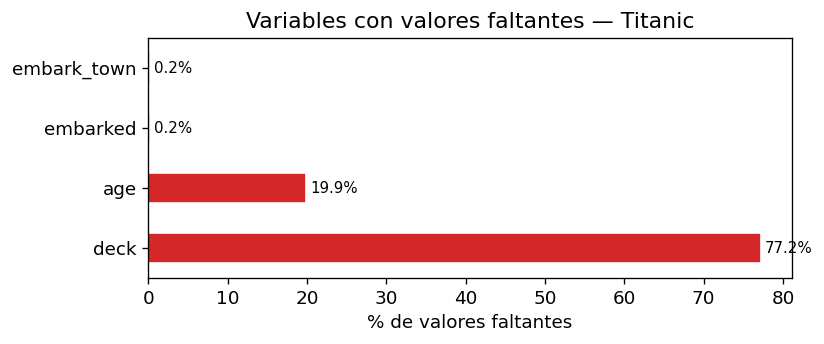

Figura guardada: f1_missing_values.png


In [ ]:
import os # Added import

# § III.4 — Diagnóstico de valores faltantes
missing = pd.DataFrame({
    'Faltantes' : df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Faltantes > 0').sort_values('Porcentaje', ascending=False)

print("=== VALORES FALTANTES ===")
print(missing.to_string())

fig, ax = plt.subplots(figsize=(7, 3))
missing['Porcentaje'].plot(kind='barh', ax=ax, color='#d62728', edgecolor='white')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Variables con valores faltantes — Titanic')
for i, v in enumerate(missing['Porcentaje']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()

# Create the directory if it does not exist
output_path = '../../reports/figures/'
os.makedirs(output_path, exist_ok=True)

plt.savefig(os.path.join(output_path, 'f1_missing_values.png'), bbox_inches='tight')
plt.show()
print("Figura guardada: f1_missing_values.png")

In [ ]:
# § III.5 — Primera caracterización global
print("=== RESUMEN .info() ===")
df.info()
print()
print(f"Observaciones (filas) : {df.shape[0]}")
print(f"Variables (columnas)  : {df.shape[1]}")
print(f"Memoria estimada      : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


=== RESUMEN .info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Observaciones (filas) : 891
Variables (columnas)  : 15

**Observaciones §III:**
- El dataset contiene **891 observaciones y 15 variables**.
- Se detectan **3 variables con valores faltantes**: `age` (177, 19.9%), `deck` (688, 77.2%)
  y `embarked` / `embark_town` (2, 0.2%).
- `deck` tiene un porcentaje de faltantes tan alto que su uso en esta fase es limitado.
- Los tipos de datos son coherentes con el dominio: `age` y `fare` como float, `survived` y
  `pclass` como enteros, variables categóricas en object.


---
## § IV — Exploración preliminar


In [ ]:
# § IV.1 — Estadísticos descriptivos: variables numéricas
print("=== ESTADÍSTICOS DESCRIPTIVOS — VARIABLES NUMÉRICAS ===")
df.describe().T.round(3)


=== ESTADÍSTICOS DESCRIPTIVOS — VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
survived,891.0000,0.3840,0.4870,0.0000,0.0000,0.0000,1.0000,1.0000
pclass,891.0000,2.3090,0.8360,1.0000,2.0000,3.0000,3.0000,3.0000
age,714.0000,29.6990,14.5260,0.4200,20.1250,28.0000,38.0000,80.0000
sibsp,891.0000,0.5230,1.1030,0.0000,0.0000,0.0000,1.0000,8.0000
parch,891.0000,0.3820,0.8060,0.0000,0.0000,0.0000,0.0000,6.0000
fare,891.0000,32.2040,49.6930,0.0000,7.9100,14.4540,31.0000,512.3290


=== DISTRIBUCIÓN DE 'survived' ===
  No sobrevivió (0):  549  (61.6%)
  Sobrevivió (1):  342  (38.4%)


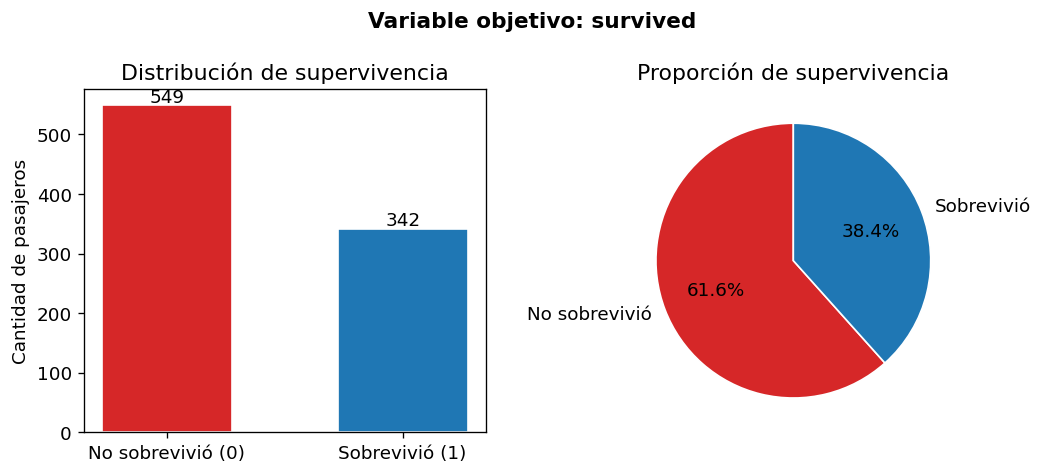

Figura guardada: f1_distribucion_survived.png


In [ ]:
# § IV.2 — Distribución de la variable objetivo: survived
conteo = df['survived'].value_counts()
pct    = df['survived'].value_counts(normalize=True) * 100

print("=== DISTRIBUCIÓN DE 'survived' ===")
for k, v in conteo.items():
    label = 'Sobrevivió' if k == 1 else 'No sobrevivió'
    print(f"  {label} ({k}): {v:4d}  ({pct[k]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Barplot
axes[0].bar(['No sobrevivió (0)', 'Sobrevivió (1)'], conteo.values,
            color=['#d62728', '#1f77b4'], edgecolor='white', width=0.55)
axes[0].set_title('Distribución de supervivencia')
axes[0].set_ylabel('Cantidad de pasajeros')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Pie
axes[1].pie(conteo.values, labels=['No sobrevivió', 'Sobrevivió'],
            colors=['#d62728', '#1f77b4'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporción de supervivencia')

plt.suptitle('Variable objetivo: survived', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_distribucion_survived.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_distribucion_survived.png")


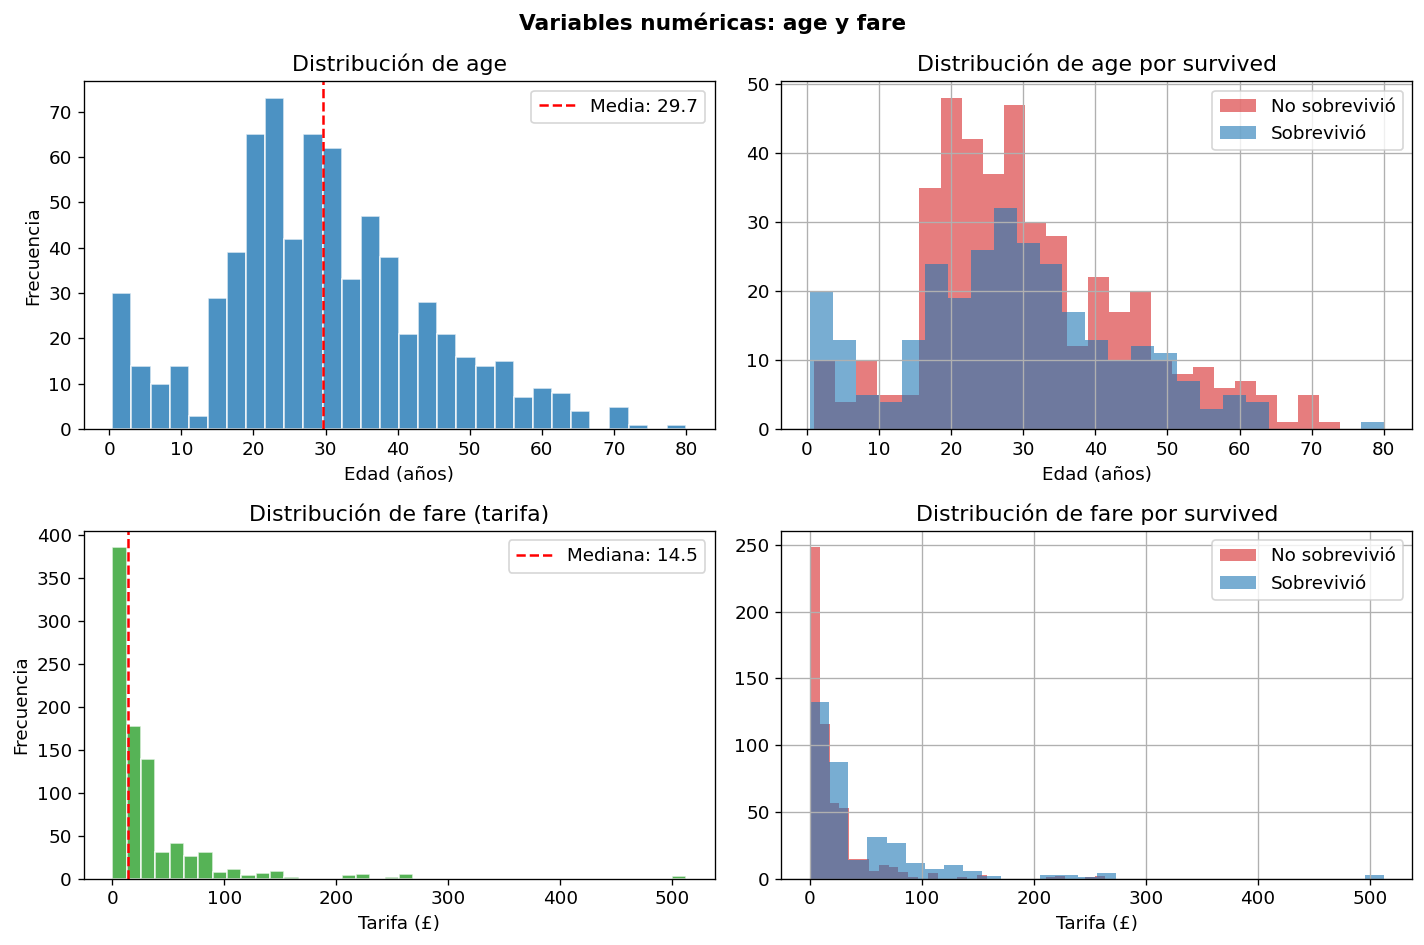

Figura guardada: f1_numericas_age_fare.png


In [ ]:
# § IV.3 — Distribución de variables numéricas clave: age y fare
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# age
axes[0, 0].hist(df['age'].dropna(), bins=30, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribución de age')
axes[0, 0].set_xlabel('Edad (años)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--',
                   label=f"Media: {df['age'].mean():.1f}")
axes[0, 0].legend()

# age por survived
df[df['survived'] == 0]['age'].dropna().hist(
    ax=axes[0, 1], bins=25, alpha=0.6, color='#d62728', label='No sobrevivió')
df[df['survived'] == 1]['age'].dropna().hist(
    ax=axes[0, 1], bins=25, alpha=0.6, color='#1f77b4', label='Sobrevivió')
axes[0, 1].set_title('Distribución de age por survived')
axes[0, 1].set_xlabel('Edad (años)')
axes[0, 1].legend()

# fare
axes[1, 0].hist(df['fare'].dropna(), bins=40, color='#2ca02c', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distribución de fare (tarifa)')
axes[1, 0].set_xlabel('Tarifa (£)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(df['fare'].median(), color='red', linestyle='--',
                   label=f"Mediana: {df['fare'].median():.1f}")
axes[1, 0].legend()

# fare por survived
df[df['survived'] == 0]['fare'].hist(
    ax=axes[1, 1], bins=30, alpha=0.6, color='#d62728', label='No sobrevivió')
df[df['survived'] == 1]['fare'].hist(
    ax=axes[1, 1], bins=30, alpha=0.6, color='#1f77b4', label='Sobrevivió')
axes[1, 1].set_title('Distribución de fare por survived')
axes[1, 1].set_xlabel('Tarifa (£)')
axes[1, 1].legend()

plt.suptitle('Variables numéricas: age y fare', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_numericas_age_fare.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_numericas_age_fare.png")


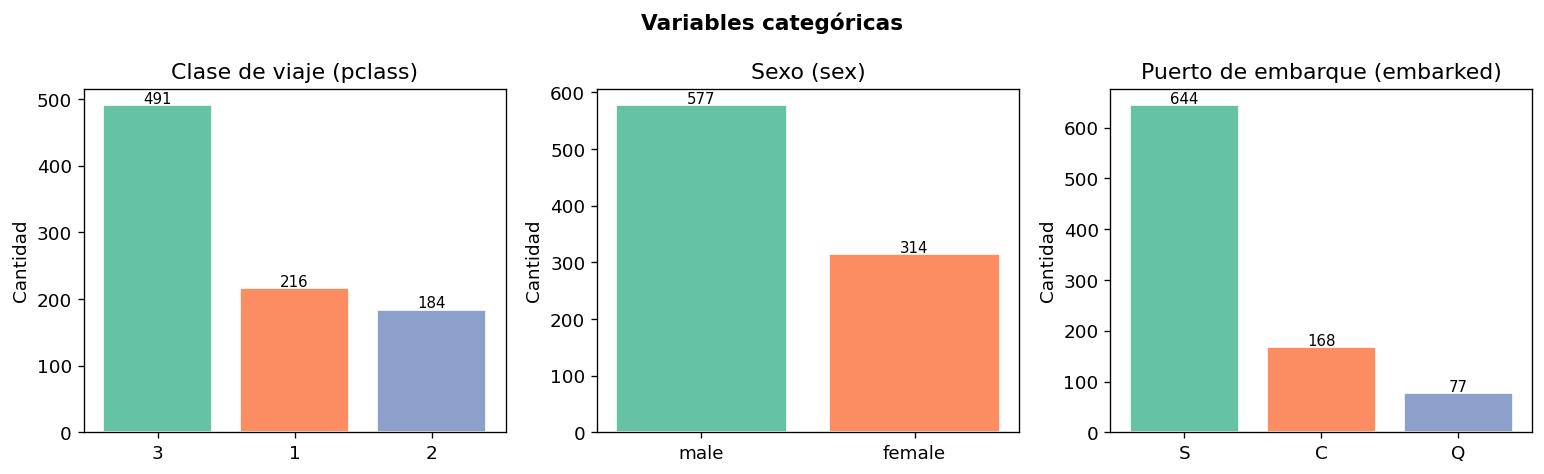

Figura guardada: f1_categoricas.png


In [ ]:
# § IV.4 — Distribución de variables categóricas clave
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['pclass', 'sex', 'embarked'],
    ['Clase de viaje (pclass)', 'Sexo (sex)', 'Puerto de embarque (embarked)']
):
    vc = df[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values,
           color=sns.color_palette('Set2', len(vc)), edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Cantidad')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 3, str(v), ha='center', fontsize=9)

plt.suptitle('Variables categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_categoricas.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_categoricas.png")


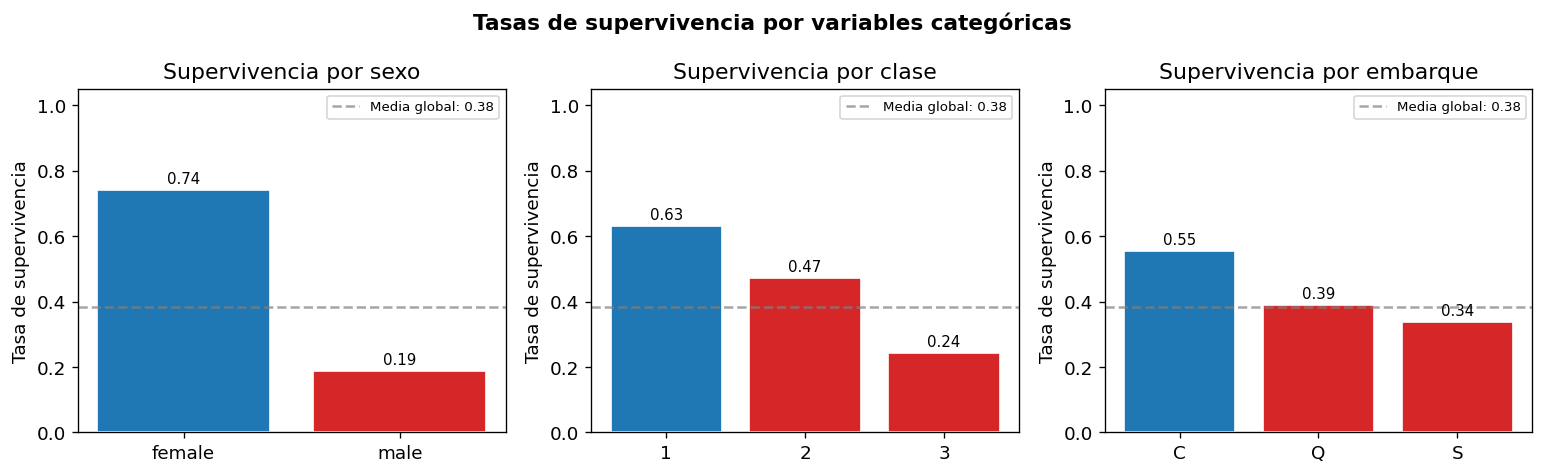

Figura guardada: f1_tasas_supervivencia.png


In [ ]:
# § IV.5 — Tasas de supervivencia por variables clave
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['sex', 'pclass', 'embarked'],
    ['Supervivencia por sexo', 'Supervivencia por clase', 'Supervivencia por embarque']
):
    tasa = df.groupby(col)['survived'].mean().sort_values(ascending=False)
    colors = ['#1f77b4' if v >= 0.5 else '#d62728' for v in tasa.values]
    ax.bar(tasa.index.astype(str), tasa.values, color=colors, edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Tasa de supervivencia')
    ax.set_ylim(0, 1.05)
    ax.axhline(df['survived'].mean(), linestyle='--', color='gray', alpha=0.7,
               label=f"Media global: {df['survived'].mean():.2f}")
    ax.legend(fontsize=8)
    for i, v in enumerate(tasa.values):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Tasas de supervivencia por variables categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_tasas_supervivencia.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_tasas_supervivencia.png")


**Observaciones §IV:**
- La tasa global de supervivencia es **38.4%** (342 de 891 pasajeros).
- **Sexo:** mujeres sobreviven a una tasa de ~74.2%, hombres solo ~18.9% — la diferencia más
  marcada entre todas las variables.
- **Clase:** clase 1 (62.9%) > clase 2 (47.3%) > clase 3 (24.2%). La clase de viaje tiene un
  efecto fuerte y gradual.
- **Edad:** la distribución es aproximadamente normal con media ~29.7 años y sesgo positivo leve.
  Los niños presentan mayor tasa de supervivencia.
- **Fare:** distribución fuertemente sesgada a la derecha — la mayoría pagó tarifas bajas, con
  valores extremos en primera clase.


---
## § V — Decisiones y transformaciones iniciales

En esta sección aplicamos el procesamiento inicial basado en los hallazgos de la exploración preliminar de las fases anteriores. Para documentar la trazabilidad de la limpieza de datos, por cada transformación detallamos **qué se hizo**, **por qué se hizo** y **qué efecto tuvo**.

### § V.1 — Eliminación de variables redundantes

*   **Qué se hizo:** Se eliminaron 6 columnas derivadas: `class`, `alive`, `who`, `adult_male`, `embark_town` y `alone`.
*   **Por qué:** Estas variables son completamente redundantes o derivadas directamente de otras columnas que ya mantendremos en el dataset (`pclass`, `survived`, `sex`, `age`, `embarked`, `sibsp` / `parch`).
*   **Qué efecto tuvo:** Reducción de la dimensionalidad del dataset, evitando la multicolinealidad y simplificando la estructura visual de los datos para los modelos y gráficos futuros.

In [ ]:
# § V.1 — Eliminación de variables redundantes
columnas_a_eliminar = ['class', 'alive', 'who', 'adult_male', 'embark_town', 'alone']
df.drop(columns=columnas_a_eliminar, inplace=True)

print(f"Columnas eliminadas. El dataset ahora tiene {df.shape[1]} columnas.")

Columnas eliminadas. El dataset ahora tiene 9 columnas.


### § V.2 — Documentación y descarte de la variable `deck`

*   **Qué se hizo:** Se descartó y eliminó la columna `deck` de nuestro set de análisis.
*   **Por qué:** Nuestro diagnóstico previo mostró que tiene un 77.2% de valores faltantes. Es un volumen tan alto que intentar imputarlo inventaría demasiada información y sesgaría los análisis.
*   **Qué efecto tuvo:** Se evita el uso de una variable no usable en esta fase, previniendo errores de interpretación.

In [ ]:
# § V.2 — Descarte de la variable 'deck'
df.drop(columns=['deck'], inplace=True)

print(f"Columna 'deck' eliminada. El dataset ahora tiene {df.shape[1]} columnas.")

Columna 'deck' eliminada. El dataset ahora tiene 8 columnas.


### § V.3 — Imputación de valores faltantes en `age`

*   **Qué se hizo:** Se imputaron los 177 valores nulos de la variable `age` utilizando la mediana estratificada según la clase de viaje (`pclass`) y el sexo (`sex`).
*   **Por qué:** La edad de los pasajeros varía sistemáticamente dependiendo del género y su poder adquisitivo (clase). Una imputación global (mediana de todos los pasajeros) distorsionaría la distribución real.
*   **Qué efecto tuvo:** Recuperamos 177 observaciones críticas para el análisis demográfico, manteniendo la coherencia de la distribución de edades por grupos sociodemográficos.

In [ ]:
# § V.3 — Imputación de 'age' con mediana estratificada
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))

faltantes_age = df['age'].isnull().sum()
print(f"Valores faltantes en 'age' después de imputar: {faltantes_age}")

Valores faltantes en 'age' después de imputar: 0


### § V.4 — Imputación de valores faltantes en `embarked`

*   **Qué se hizo:** Se rellenaron los 2 valores faltantes en la columna `embarked` utilizando la moda (el puerto más frecuente).
*   **Por qué:** Dado que solo faltan 2 registros (0.2%), imputar estadísticamente con la categoría mayoritaria es el enfoque más seguro y simple sin alterar la distribución de la variable categórica.
*   **Qué efecto tuvo:** Se completó el 100% de la columna categórica de puerto de embarque sin tener que sacrificar las filas.

In [ ]:
# § V.4 — Imputación de 'embarked' con la moda
moda_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(moda_embarked, inplace=True)

faltantes_embarked = df['embarked'].isnull().sum()
print(f"Valores faltantes en 'embarked' después de imputar: {faltantes_embarked} (Moda usada: {moda_embarked})")

Valores faltantes en 'embarked' después de imputar: 0 (Moda usada: S)


### § V.5 — Creación de la variable `family_size`

*   **Qué se hizo:** Se creó una nueva característica matemática llamada `family_size`, producto de la suma de `sibsp` (hermanos/cónyuges) y `parch` (padres/hijos).
*   **Por qué:** En lugar de analizar las relaciones familiares por separado, combinar estas variables permite medir directamente la magnitud total del grupo familiar con el que viajaba un pasajero.
*   **Qué efecto tuvo:** Se generó un nuevo atributo numérico condensado que será clave para analizar si el tamaño del grupo familiar favoreció o entorpeció las probabilidades de supervivencia.

In [ ]:
# § V.5 — Creación de la nueva variable 'family_size'
df['family_size'] = df['sibsp'] + df['parch']

print("Nueva columna 'family_size' creada correctamente.")

Nueva columna 'family_size' creada correctamente.


### § V.6 — Verificación de transformaciones

A continuación, validamos que el dataset no tenga valores faltantes y verificamos la estructura final tras aplicar todas las decisiones de limpieza.

In [ ]:
# § V.6 — Verificación de resultados finales de la Sección V
print("=== ESTADO FINAL DE VALORES FALTANTES ===")
print(df.isnull().sum())
print("\n=== PRIMERAS 5 FILAS TRAS TRANSFORMACIONES ===")
display(df.head())
print(f"\nDimensiones finales del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")

=== ESTADO FINAL DE VALORES FALTANTES ===
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
family_size    0
dtype: int64

=== PRIMERAS 5 FILAS TRAS TRANSFORMACIONES ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size
0,0,3,male,22.0000,1,0,7.2500,S,1
1,1,1,female,38.0000,1,0,71.2833,C,1
2,1,3,female,26.0000,0,0,7.9250,S,0
3,1,1,female,35.0000,1,0,53.1000,S,1
4,0,3,male,35.0000,0,0,8.0500,S,0



Dimensiones finales del dataset: 891 filas × 9 columnas


### S6 - Resultados e Interpretación Inicial

En esta sección damos cierre al primer ciclo de exploración, cruzando las variables trabajadas en la S4 y S5 para responder las preguntas planteadas en la S3. Además, se analiza la interacción entre sex y pclass, el efecto del tamaño del grupo familiar considerado en la variable family_size sobre la supervivencia y se sintetizan los hallazgos en una tabla de resumen.


=== TABLA DE TASA DE SUPERVIVENCIA POR SEXO Y CLASE ===
pclass      1      2      3
sex                        
female 0.9680 0.9210 0.5000
male   0.3690 0.1570 0.1350


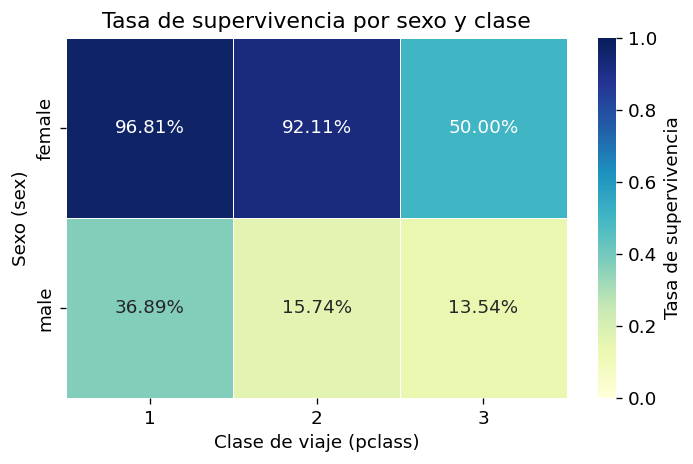

Figura guardada: f1_heatmap_sex_pclass.png


In [ ]:
# 6.1 Heatmap con tasa de supervivencia por sexo y clase

tabla_sex_pclass = df.pivot_table(
    values='survived',
    index='sex',
    columns='pclass',
    aggfunc='mean'
)
print("=== TABLA DE TASA DE SUPERVIVENCIA POR SEXO Y CLASE ===")
print(tabla_sex_pclass.round(3))

fig, ax = plt.subplots(figsize=(6,4))

sns.heatmap(
    tabla_sex_pclass,
    annot=True,
    fmt='.2%',
    cmap='YlGnBu',
    vmin = 0,
    vmax = 1,
    linewidths=0.5,
    cbar_kws={'label': 'Tasa de supervivencia'},
    ax=ax
)
ax.set_title('Tasa de supervivencia por sexo y clase')
ax.set_xlabel('Clase de viaje (pclass)')
ax.set_ylabel('Sexo (sex)')
plt.tight_layout()

plt.savefig('../../reports/figures/f1_heatmap_sex_pclass.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_heatmap_sex_pclass.png")


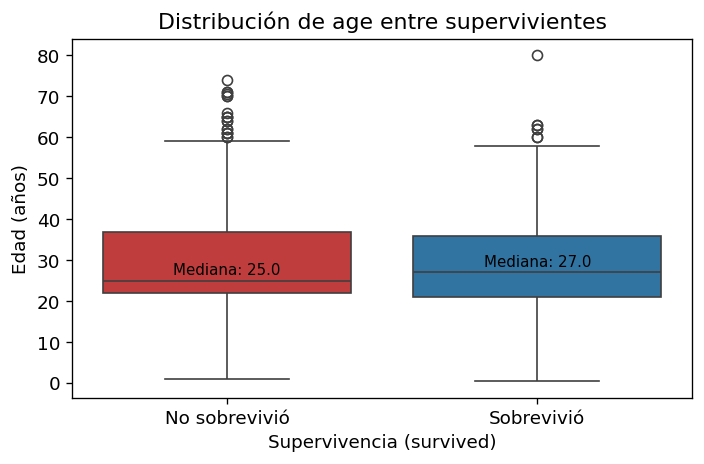


Figura guardada: f1_boxplot_age_survived.png


In [ ]:
# 6.2 - Boxplot de age por survived
# Distribución de age entre supervivientes

fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(
    x='survived',
    y='age',
    hue='survived',
    data=df,
    palette={0: '#d62728',1: '#1f77b4'},
    legend=False,
    ax=ax
)

medianas_age = df.groupby('survived')['age'].median()
for x, mediana in medianas_age.items():
  ax.text(x, mediana + 1.5, f'Mediana: {mediana:.1f}',
        ha='center', fontsize=9)

ax.set_title('Distribución de age entre supervivientes')
ax.set_xlabel('Supervivencia (survived)')
ax.set_ylabel('Edad (años)')
ax.set_xticks([0, 1], ['No sobrevivió', 'Sobrevivió'])

plt.tight_layout()
plt.savefig('../../reports/figures/f1_boxplot_age_survived.png', bbox_inches='tight')
plt.show()
print()
print("Figura guardada: f1_boxplot_age_survived.png")


=== TABLA DE TASA DE SUPERVIVENCIA SEGÚN EL TAMAÑO DEL GRUPO FAMILIAR ===
             tasa_supervivencia  cantidad_pasajeros
family_size                                        
0                        0.3040                 537
1                        0.5530                 161
2                        0.5780                 102
3                        0.7240                  29
4                        0.2000                  15
5                        0.1360                  22
6                        0.3330                  12
7                        0.0000                   6
10                       0.0000                   7



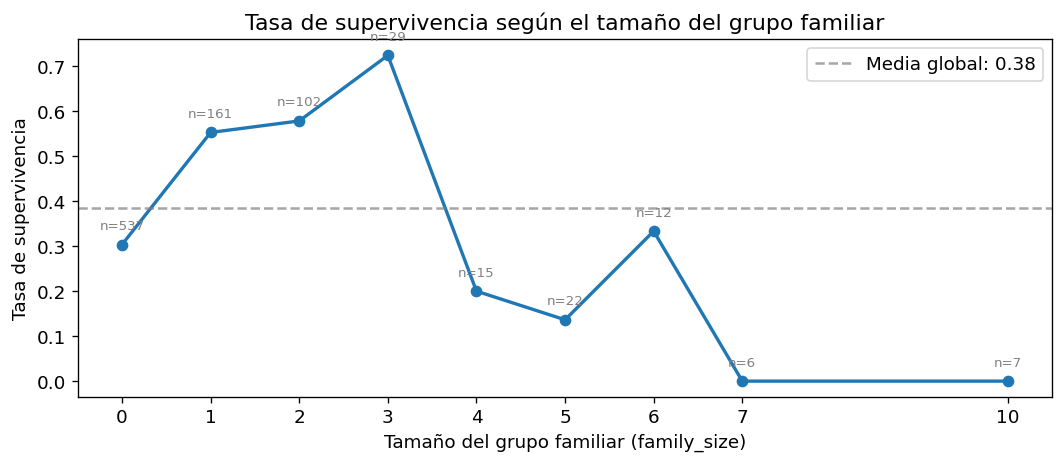

Figura guardada: f1_tasa_supervivencia_family_size.png


In [ ]:
# 6.3 - Tasa de supervivencia según el tamaño del grupo familiar

# Se agrupa el dataset por 'family_size' y se calcula la tasa de supervivencia

tasa_family = df.groupby('family_size')['survived'].agg(['mean','count'])
tasa_family.columns = ['tasa_supervivencia','cantidad_pasajeros']

print("=== TABLA DE TASA DE SUPERVIVENCIA SEGÚN EL TAMAÑO DEL GRUPO FAMILIAR ===")
print(tasa_family.round(3))
print()
fig, ax = plt.subplots(figsize=(9,4))

ax.plot(tasa_family.index,
        tasa_family['tasa_supervivencia'],
        marker='o',
        color = '#1f77b4',
        linewidth = 2
        )

for x,y,n in zip(tasa_family.index,
               tasa_family['tasa_supervivencia'],
               tasa_family['cantidad_pasajeros']):
    ax.annotate(f'n={n}',
                (x,y),
                textcoords="offset points",
                xytext=(0,9),
                ha ='center',
                fontsize = 8,
                color = 'gray')

ax.axhline(df['survived'].mean(),
               linestyle='--',
               color='gray',
               alpha=0.7,
               label=f"Media global: {df['survived'].mean():.2f}")
ax.set_title('Tasa de supervivencia según el tamaño del grupo familiar')
ax.set_xlabel('Tamaño del grupo familiar (family_size)')
ax.set_ylabel('Tasa de supervivencia')
ax.set_xticks(tasa_family.index)
ax.legend()
#ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../../reports/figures/f1_tasa_supervivencia_family_size.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_tasa_supervivencia_family_size.png")


In [ ]:
# 6.4 - Tabla de resumen - Respuestas a preguntas exploratorias

pd.set_option('display.max_colwidth',None)

tasa_sex = df.groupby('sex')['survived'].mean()
tasa_pclass = df.groupby('pclass')['survived'].mean()

resumen_preguntas = pd.DataFrame({
    'Pregunta': [
        '1. Distribución de supervivientes y no supervivientes',
        '2. Variables con valores faltantes y magnitud',
        '3. Diferencias en supervivencia por sexo, clase y edad',
        "4. Distribución de 'age' e implicancias",
        '5. Variables redundantes o derivadas a simplificar'
    ],
    'Respuesta resumida':[
        f"{df['survived'].mean()*100:.1f}% de los {len(df)} pasajeros sobrevivió."
        f"{100 - df['survived'].mean()*100:.1f}% no sobrevivieron (ver S4.2)",
        "Antes de la limpieza: 'age' tenía 19.9% de faltantes, 'deck' un 77.2% y "
        "'embarked'/'embark_town' un 0.2%. 'age' se imputó con la mediana estratificada "
        "por clase y sexo, 'embarked' con la moda, y 'deck' se descartó por exceso de "
        "faltantes (ver S3.4 y S5.2- S5.4).",

        f"Sí, son marcadas, las mujeres sobreviven en un {tasa_sex['female']*100:.1f}% de los casos frente a un {tasa_sex['male']*100:.1f}% en los hombres. La clase 1 "
        f"({tasa_pclass[1]*100:.1f}%) supera ampliamente a la clase 3 "
        f"({tasa_pclass[3]*100:.1f}%). El cruce sexo-clase del heatmap (S6.1) muestra que el efecto de la clase es aún más fuerte entre las mujeres.",

        f"Distribución aproximadamente normal, con media de {df['age'].mean():.1f} años y un leve sesgo positivo."
        " Los pasajeros de menor edad tienden a mostrar una tasa de supervivencia más alta (ver S4.3).",

        "Se identificaron 6 columnas redundantes o derivadas ('class', 'alive', 'who', 'adult_male', 'embark_town', 'alone'), eliminadas por replicar información ya "
        "contenida en otras variables del dataset (ver S5.1)."
    ]
})

print("=== TABLA RESUMEN — RESPUESTAS A LAS PREGUNTAS EXPLORATORIAS (S2.3) ===")
display(resumen_preguntas)


=== TABLA RESUMEN — RESPUESTAS A LAS PREGUNTAS EXPLORATORIAS (S2.3) ===


,Pregunta,Respuesta resumida
0,1. Distribución de supervivientes y no supervivientes,38.4% de los 891 pasajeros sobrevivió.61.6% no sobrevivieron (ver S4.2)
1,2. Variables con valores faltantes y magnitud,"Antes de la limpieza: 'age' tenía 19.9% de faltantes, 'deck' un 77.2% y 'embarked'/'embark_town' un 0.2%. 'age' se imputó con la mediana estratificada por clase y sexo, 'embarked' con la moda, y 'deck' se descartó por exceso de faltantes (ver S3.4 y S5.2- S5.4)."
2,"3. Diferencias en supervivencia por sexo, clase y edad","Sí, son marcadas, las mujeres sobreviven en un 74.2% de los casos frente a un 18.9% en los hombres. La clase 1 (63.0%) supera ampliamente a la clase 3 (24.2%). El cruce sexo-clase del heatmap (S6.1) muestra que el efecto de la clase es aún más fuerte entre las mujeres."
3,4. Distribución de 'age' e implicancias,"Distribución aproximadamente normal, con media de 29.1 años y un leve sesgo positivo. Los pasajeros de menor edad tienden a mostrar una tasa de supervivencia más alta (ver S4.3)."
4,5. Variables redundantes o derivadas a simplificar,"Se identificaron 6 columnas redundantes o derivadas ('class', 'alive', 'who', 'adult_male', 'embark_town', 'alone'), eliminadas por replicar información ya contenida en otras variables del dataset (ver S5.1)."


**Hallazgos S6:**

- **Interacción sexo × clase:** el heatmap de S6.1 confirma que el sexo es, un factor determinante de la supervivencia, pero su efecto no es homogéneo, ya que las mujeres de primera y segunda clase alcanzan tasas de supervivencia muy altas, mientras que los hombres de tercera clase presentan las tasas más bajas de todo el dataset. Esto podría significar que el protocolo de evacuación tuvo influencia por el privilegio de clase, amplificando las diferencias de tasas de supervivencia entre estos grupos.
- **Edad y supervivencia:** el boxplot de S6.2 muestra que las distribuciones de **age** para ambos grupos muestran medianas parecidas (25 años en quienes no sobrevivieron y 27 años en quienes sí). La diferencia más relevante no está en la mediana, sino en que el grupo de sobrevivientes concentra más casos en edades bajas (niños), lo que sería consistente con el criterio de prioridad por edad en la evacuación.
- **Tamaño del grupo familiar:** la relación entre **family_size** y la tasa de supervivencia (S6.3) **no es lineal**. Viajar completamente solo (**family_size = 0**) se asocia a una tasa menor que viajar en grupos pequeños (1 a 3 integrantes), pero en grupos muy numerosos la tasa vuelve a caer. Una explicación podría ser que coordinar a una familia grande dificultó llegar a tiempo a los botes salvavidas, mientras que un grupo pequeño permitía apoyo mutuo sin perder tiempo en coordinación.
- **Cierre de las preguntas exploratorias:** la tabla resumen de S6.4 muestra que las 5 preguntas planteadas en S2.3 quedan respondidas con evidencia concreta: se cuantificó la distribución de **survived**, se documentó el tratamiento de los valores faltantes, se identificaron los factores con mayor asociación a la supervivencia (sexo y clase, con **age** y **family_size** como factores secundarios) y se justificó la eliminación de variables redundantes.

- **Observación importante a tener en cuenta:** los hallazgos de esta fase se basan en asociaciones simples (promedios y tablas cruzadas entre dos variables). No se controla por múltiples variables al mismo tiempo, por lo que estos patrones deben entenderse como **hipótesis exploratorias** que podrán profundizarse con modelos estadísticos o de machine learning en fases posteriores del proyecto.

## S VII — Supuestos y limitaciones

### S VII.1 — Supuestos del análisis

| Supuesto | Justificación |
|---|---|
| El dataset Titanic es representativo para el análisis exploratorio realizado | Se utiliza como una muestra histórica de pasajeros y tripulantes del Titanic; los resultados permiten identificar patrones dentro del dataset, pero no necesariamente representan a todas las personas involucradas en el desastre. |
| La variable `survived` representa correctamente la supervivencia | Se utiliza como variable objetivo binaria; `0` corresponde a no sobrevivir y `1` a sobrevivir. |
| La imputación de `age` mediante la mediana agrupada por `pclass` y `sex` es adecuada | La edad puede presentar diferencias según la clase de viaje y el sexo; por ello, una imputación estratificada resulta más apropiada que utilizar una única mediana global. |
| La imputación de `embarked` mediante la moda es válida | Solo existían 2 valores faltantes, equivalentes aproximadamente al 0,2% del dataset; por lo tanto, el impacto sobre la distribución general se considera reducido. |
| La variable `deck` no es suficientemente utilizable en esta fase | Presentaba aproximadamente un 77,2% de valores faltantes; conservarla o imputarla podría introducir demasiada información artificial y afectar la interpretación. |
| `family_size` permite representar de forma resumida el tamaño del grupo familiar | Se construyó como la suma de `sibsp` y `parch`, permitiendo analizar el tamaño del grupo familiar de manera conjunta. |

### S VII.2 — Limitaciones del análisis

| Limitación | Impacto en los resultados |
|---|---|
| El dataset corresponde a una muestra histórica específica | Los resultados no deben generalizarse automáticamente a otros desastres marítimos o poblaciones diferentes. |
| La variable `deck` fue descartada debido a su alto porcentaje de valores faltantes | Se pierde la posibilidad de estudiar la relación entre la cubierta asignada y la supervivencia. |
| La variable `age` fue imputada | Los valores completados son estimaciones estadísticas y no corresponden necesariamente a las edades reales de los pasajeros. |
| La imputación de `embarked` mediante la moda puede ocultar diferencias individuales | Los 2 registros faltantes fueron asignados al puerto más frecuente, lo que simplifica el tratamiento, pero no garantiza que esa haya sido su categoría original. |
| El análisis se basa principalmente en asociaciones bivariadas | No se controlan simultáneamente variables como sexo, clase, edad y tamaño familiar; por lo tanto, no se pueden establecer relaciones causales. |
| No se incorporaron variables externas | No se analizaron factores como ubicación durante el hundimiento, acceso a botes salvavidas, tripulación, hora de evacuación u otras condiciones operativas. |

### S VII.3 — Aspectos pendientes para la Fase 2

- Profundizar el análisis mediante modelos estadísticos o de machine learning.
- Evaluar la contribución conjunta de `sex`, `pclass`, `age`, `fare` y `family_size`.
- Analizar posibles interacciones entre variables.
- Estudiar la capacidad predictiva de distintos modelos de clasificación.
- Evaluar métricas como accuracy, precision, recall y F1-score.
- Separar los resultados exploratorios de las conclusiones causales.
- Investigar si existen sesgos derivados de los valores faltantes y de las imputaciones realizadas.


## S VIII — Conclusiones

El análisis exploratorio permitió caracterizar el dataset Titanic, identificar problemas de calidad de datos y establecer un proceso de preparación previo a etapas posteriores de análisis.

Durante la etapa de diagnóstico se identificaron valores faltantes principalmente en las variables `age`, `deck` y `embarked`. A partir de este diagnóstico se aplicaron estrategias diferenciadas de tratamiento: se eliminó `deck` debido a su elevada proporción de datos faltantes, se imputó `age` utilizando la mediana agrupada por `pclass` y `sex`, y se completaron los valores faltantes de `embarked` mediante su moda.

Además, se eliminaron variables redundantes o derivadas que no aportaban información adicional para el análisis exploratorio y se construyó la variable `family_size` a partir de `sibsp` y `parch`, permitiendo representar de manera resumida el tamaño del grupo familiar.

Los resultados obtenidos permiten establecer una base de datos preparada y documentada para continuar con una segunda fase de análisis. En particular, será posible profundizar en la relación conjunta entre características demográficas, clase de viaje, tarifa y composición familiar respecto de la supervivencia.

Finalmente, es importante considerar que los resultados corresponden a un análisis exploratorio del dataset disponible. Por lo tanto, las asociaciones identificadas no deben interpretarse como relaciones causales ni generalizarse automáticamente a otras poblaciones.

### S VIII.1 — Principales hallazgos de la Fase 1

| Hallazgo | Evidencia / interpretación |
|---|---|
| **1. La supervivencia presenta diferencias marcadas según sexo y clase** | Las mujeres presentan una tasa de supervivencia considerablemente mayor que los hombres. Además, la primera clase presenta mejores tasas que la tercera, observándose un efecto conjunto entre sexo y clase en el heatmap de S6.1. |
| **2. Los valores faltantes se concentran principalmente en `deck` y `age`** | `deck` presenta aproximadamente un 77,2% de valores faltantes, por lo que fue descartada. `age` presentó cerca de un 19,9% de faltantes y fue imputada mediante la mediana estratificada por `pclass` y `sex`. |
| **3. La edad presenta diferencias exploratorias entre supervivientes y no supervivientes** | El boxplot muestra medianas cercanas entre ambos grupos, pero una mayor concentración de pasajeros jóvenes entre quienes sobrevivieron. Este resultado debe interpretarse como una asociación exploratoria. |
| **4. El tamaño del grupo familiar no presenta una relación lineal con la supervivencia** | Los grupos pequeños presentan mejores tasas que quienes viajaban completamente solos, mientras que los grupos muy numerosos vuelven a mostrar una disminución de la supervivencia. |
| **5. Se identificaron y eliminaron variables redundantes o derivadas** | Se eliminaron `class`, `alive`, `who`, `adult_male`, `embark_town` y `alone`, debido a que replicaban información ya contenida en otras variables del dataset. |
| **6. El dataset quedó preparado para análisis posteriores** | Después del tratamiento de valores faltantes, eliminación de variables redundantes y creación de `family_size`, se dispone de una base documentada para profundizar el análisis mediante métodos estadísticos y modelos predictivos en la Fase 2. |

### S VIII.1 — Cierre

El proceso desarrollado permitió pasar desde la revisión inicial de los datos hasta la construcción de un dataset preparado para análisis posteriores, manteniendo trazabilidad sobre las principales decisiones de limpieza y transformación.

Con esto, la Fase 1 queda finalizada y se establece una base para continuar con análisis estadístico y modelos predictivos en la Fase 2.